In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

import scipy.stats
import umap

import time

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers

from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

import numpy as np
from scipy.stats import gaussian_kde


from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *


rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

E0529 11:54:48.006653   21562 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0529 11:54:48.020265   20857 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


(1797, 64)


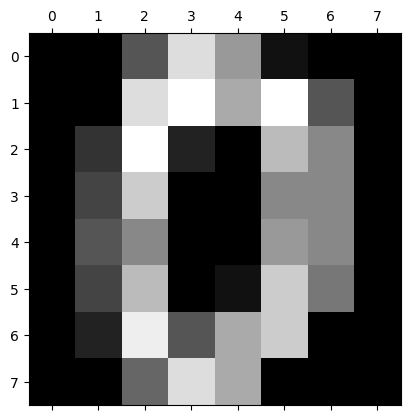

In [2]:
mnist = fetch_openml("mnist_784")
mnist_data = np.array(mnist.data) / 255.0
mnist_targets = np.array(mnist.target).astype(int)
digits = load_digits()
print(digits.data.shape)

plt.matshow(digits.images[0], cmap="gray")
plt.show()

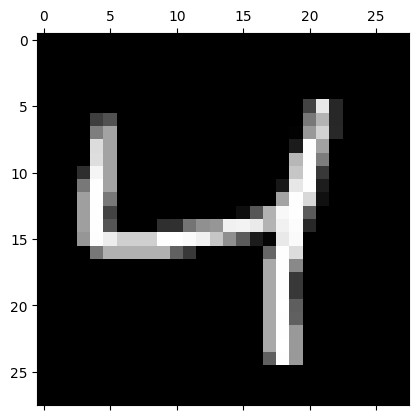

In [3]:
plt.matshow(mnist_data[2].reshape(28, 28), cmap="gray")
plt.show()

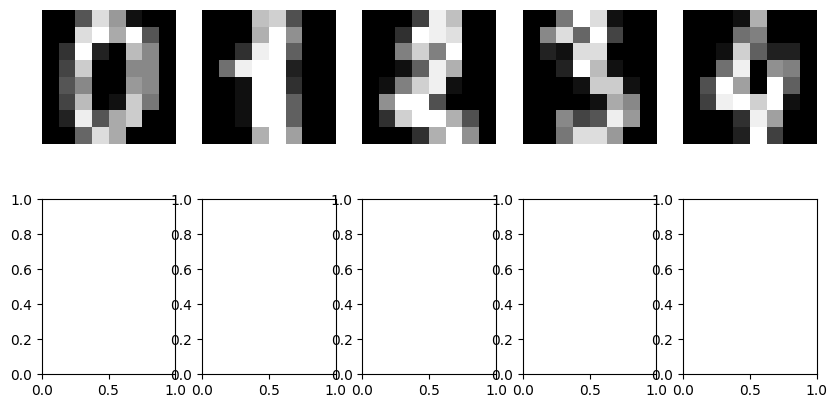

In [4]:
def plot_images(imgs, shape=(28, 28)):
    assert len(imgs) <= 10, "Can only plot up to 10 images"
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, img in enumerate(imgs):
        axes[i//5, i%5].imshow(img.reshape(*shape), cmap="gray")
        axes[i//5, i%5].axis("off")
    plt.show()

plot_images(digits.data[:5], shape=(8, 8))

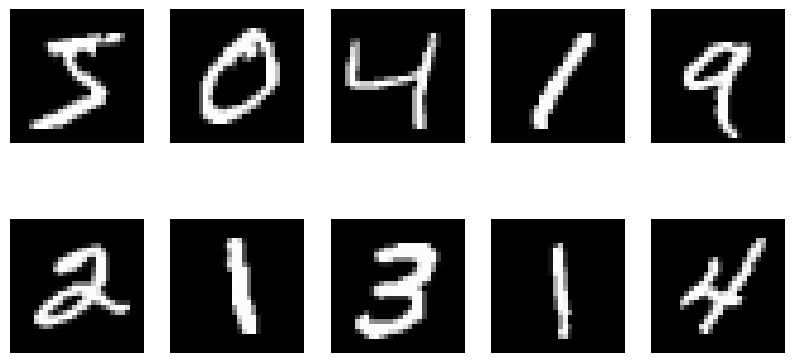

In [5]:
plot_images(mnist_data[:10], shape=(28, 28))

In [6]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )





In [7]:
rng_key, s1, s2, s3 = jax.random.split(rng_key, 4)

diff = mnist_data.max() - mnist_data.min()
mnist_data = (mnist_data - mnist_data.min()) / diff if mnist_data.max() != mnist_data.min() else mnist_data

X, X_test, y, y_test = sklearn.model_selection.train_test_split(mnist_data, mnist_targets, test_size=0.2, random_state=42)

#dequantize the data from 16 colors (1-16) to numbers between 0 and 1. Adding noise:

X = jnp.clip(X + 0.05 * jax.random.normal(s1, X.shape), 0, 1)

#Then binarize
X = jax.random.bernoulli(s2, X)
#X = (X > 0.5).astype(float)


# No noise for test set, just binarize it:
X_test = jax.random.bernoulli(s3, X_test)
#X_test = (X_test > 0.5).astype(float)

#Make 1 if above 0.5, 0 otherwise:
#X = (X > 0.5).astype(float)

batch_size = 128

dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]
dataloader_test = [X_test[i:i+batch_size] for i in range(0, len(X_test), batch_size)]



# Test the effectiveness of stein particles



In [8]:
def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(out_dim),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(f_dim),
        stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(h_dim),
    )

In [9]:


out_dim = X.shape[1]
hidden_dim =128
z_dim = 50
m_dim = 5
h_dim = 20


lr=5e-3

def lr_scheduler(lr_start=5e-3, decay_rate=0.9, decay_steps=300, floor=1e-5):
    def schedule(step):
        return lr_start * (decay_rate ** (step // decay_steps)) + floor
    return schedule


decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
f_args = {"hidden_dim": z_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim, "variance_floor": 0.05}
h_args = {"hidden_dim": h_dim, "h_dim": z_dim}
flow_args = {"input_dim": m_dim, "hidden_dims": [m_dim], "steps": 0, "inv": True} # 0 means identity transform

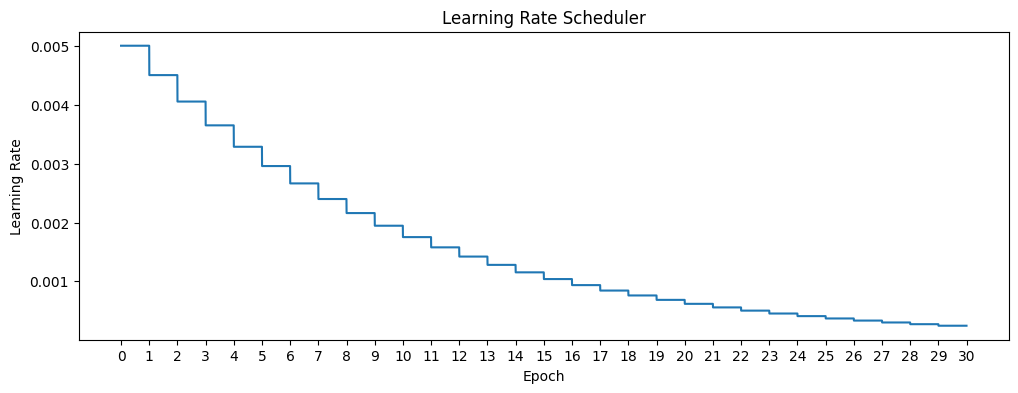

In [10]:

epochs = 30
steps = len(X)/batch_size * epochs
lr_scheduler_fn = lr_scheduler(lr, decay_rate=0.9, decay_steps=steps/30, floor=1e-5)
#plot lr scheduler for 20000 steps
lrs = [lr_scheduler_fn(step) for step in range(int(steps))]
plt.figure(figsize=(12, 4))
plt.plot(lrs)

plt.title("Learning Rate Scheduler")

plt.xticks(np.linspace(0, steps, epochs+1), [f"{i}" for i in range(epochs+1)])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()



adam = optim.ClippedAdam(lr_scheduler_fn, clip_norm=10)

In [11]:
debug = False
jax.config.update("jax_debug_nans", debug)
jax.config.update("jax_disable_jit", False)



rng_key, sub_key = jax.random.split(rng_key)


In [12]:
stein_particles_counts = [3]
trained_models = []


for num_particles in stein_particles_counts:

    smivae74 = SteinHierarchicalVAE(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, 2, z_dim, m_dim, normalizing_flow, flow_args, model_mode="b")
    #time the training process:
    start_time = time.time()
    particle_norms = smivae74.train(dataloader, len(X), adam, num_epochs=epochs, rng_key=sub_key, num_stein_particles=num_particles, annealed_sites=["z0", "z1", "z2", "z3", "m"], 
                annealing_epochs=10, bandwidth_scaler=0.03, num_elbo_particles=50)
    end_time = time.time()
    print(f"Number of particles: {num_particles}, Time taken: {end_time - start_time:.2f} seconds")
    trained_models.append((num_particles, smivae74, end_time - start_time, particle_norms))

KeyboardInterrupt: 

In [ ]:
# import pickle
# with open("smivae_trained2905_30epochs_3stein_50elbo.pkl", "wb") as f:
#     pickle.dump(trained_models, f)




In [13]:
import pickle

with open("smivae_trained2905_200epochs_3stein.pkl", "rb") as f:
    trained_models= pickle.load(f)

/tmp/ipykernel_20857/386221638.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


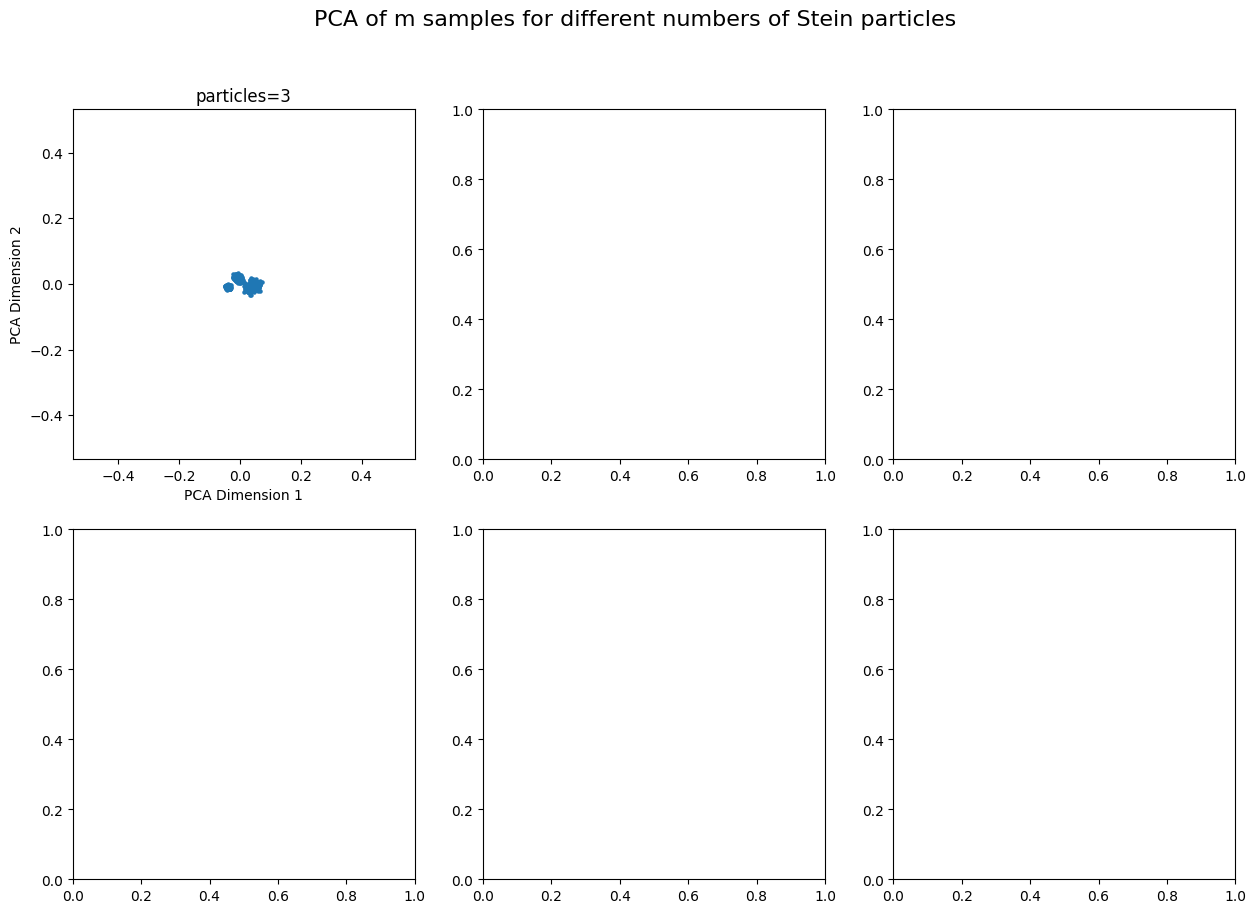

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

for i, (num_particles, model, time_taken, particle_norms) in enumerate(trained_models):
    # colunm (c) and row (r):
    c = i // 3
    r = i % 3

    smivae74 = trained_models[i][1] # Get the model with 25 particles

    sites=smivae74.sample(sub_key, 1000)

    # plot sites["m"] using pca:
    pca = PCA(n_components=2)
    m_embedding = pca.fit_transform(sites["m"])
    ax[c, r].scatter(m_embedding[:, 0], m_embedding[:, 1], s=5, alpha=1, label="Samples from m")
    ax[c, r].set_title(f"particles={num_particles}")
    ax[c, r].set_xlabel("PCA Dimension 1")
    ax[c, r].set_ylabel("PCA Dimension 2")

#share axes, use min and max of all embeddings to set limits:
all_embeddings = np.concatenate([PCA(n_components=2).fit_transform(trained_models[i][1].sample(sub_key, 1000)["m"]) for i in range(len(trained_models))], axis=0)
x_min, x_max = all_embeddings[:, 0].min() - 0.5, all_embeddings[:, 0].max() + 0.5
y_min, y_max = all_embeddings[:, 1].min() - 0.5, all_embeddings[:, 1].max() + 0.5
for i in range(len(trained_models)):
    c = i // 3
    r = i % 3
    ax[c, r].set_xlim(x_min, x_max)
    ax[c, r].set_ylim(y_min, y_max)

fig.suptitle("PCA of m samples for different numbers of Stein particles", fontsize=16)
fig.show()


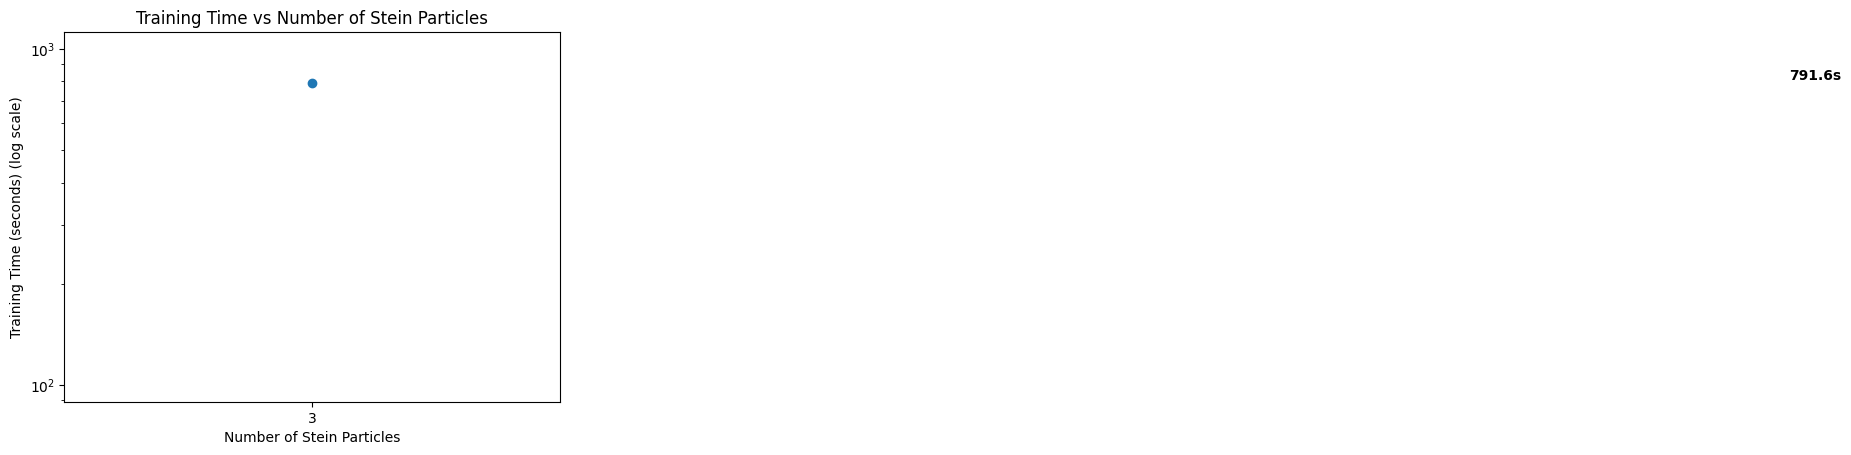

In [15]:
num_particles_list = [model[0] for model in trained_models]
times = [model[2] for model in trained_models]
plt.plot(num_particles_list, times, marker="o")
plt.title("Training Time vs Number of Stein Particles")
plt.xlabel("Number of Stein Particles")
plt.ylabel("Training Time (seconds) (log scale)")

#show only numbers on x-axis:
plt.xticks(num_particles_list)
#show the number in seconds next to each point:
for i, time in enumerate(times):
    #bold
    plt.text(num_particles_list[i]+1, times[i], f"{time:.1f}s", ha="center", va="bottom", fontweight="bold")
plt.yscale("log")

plt.show()

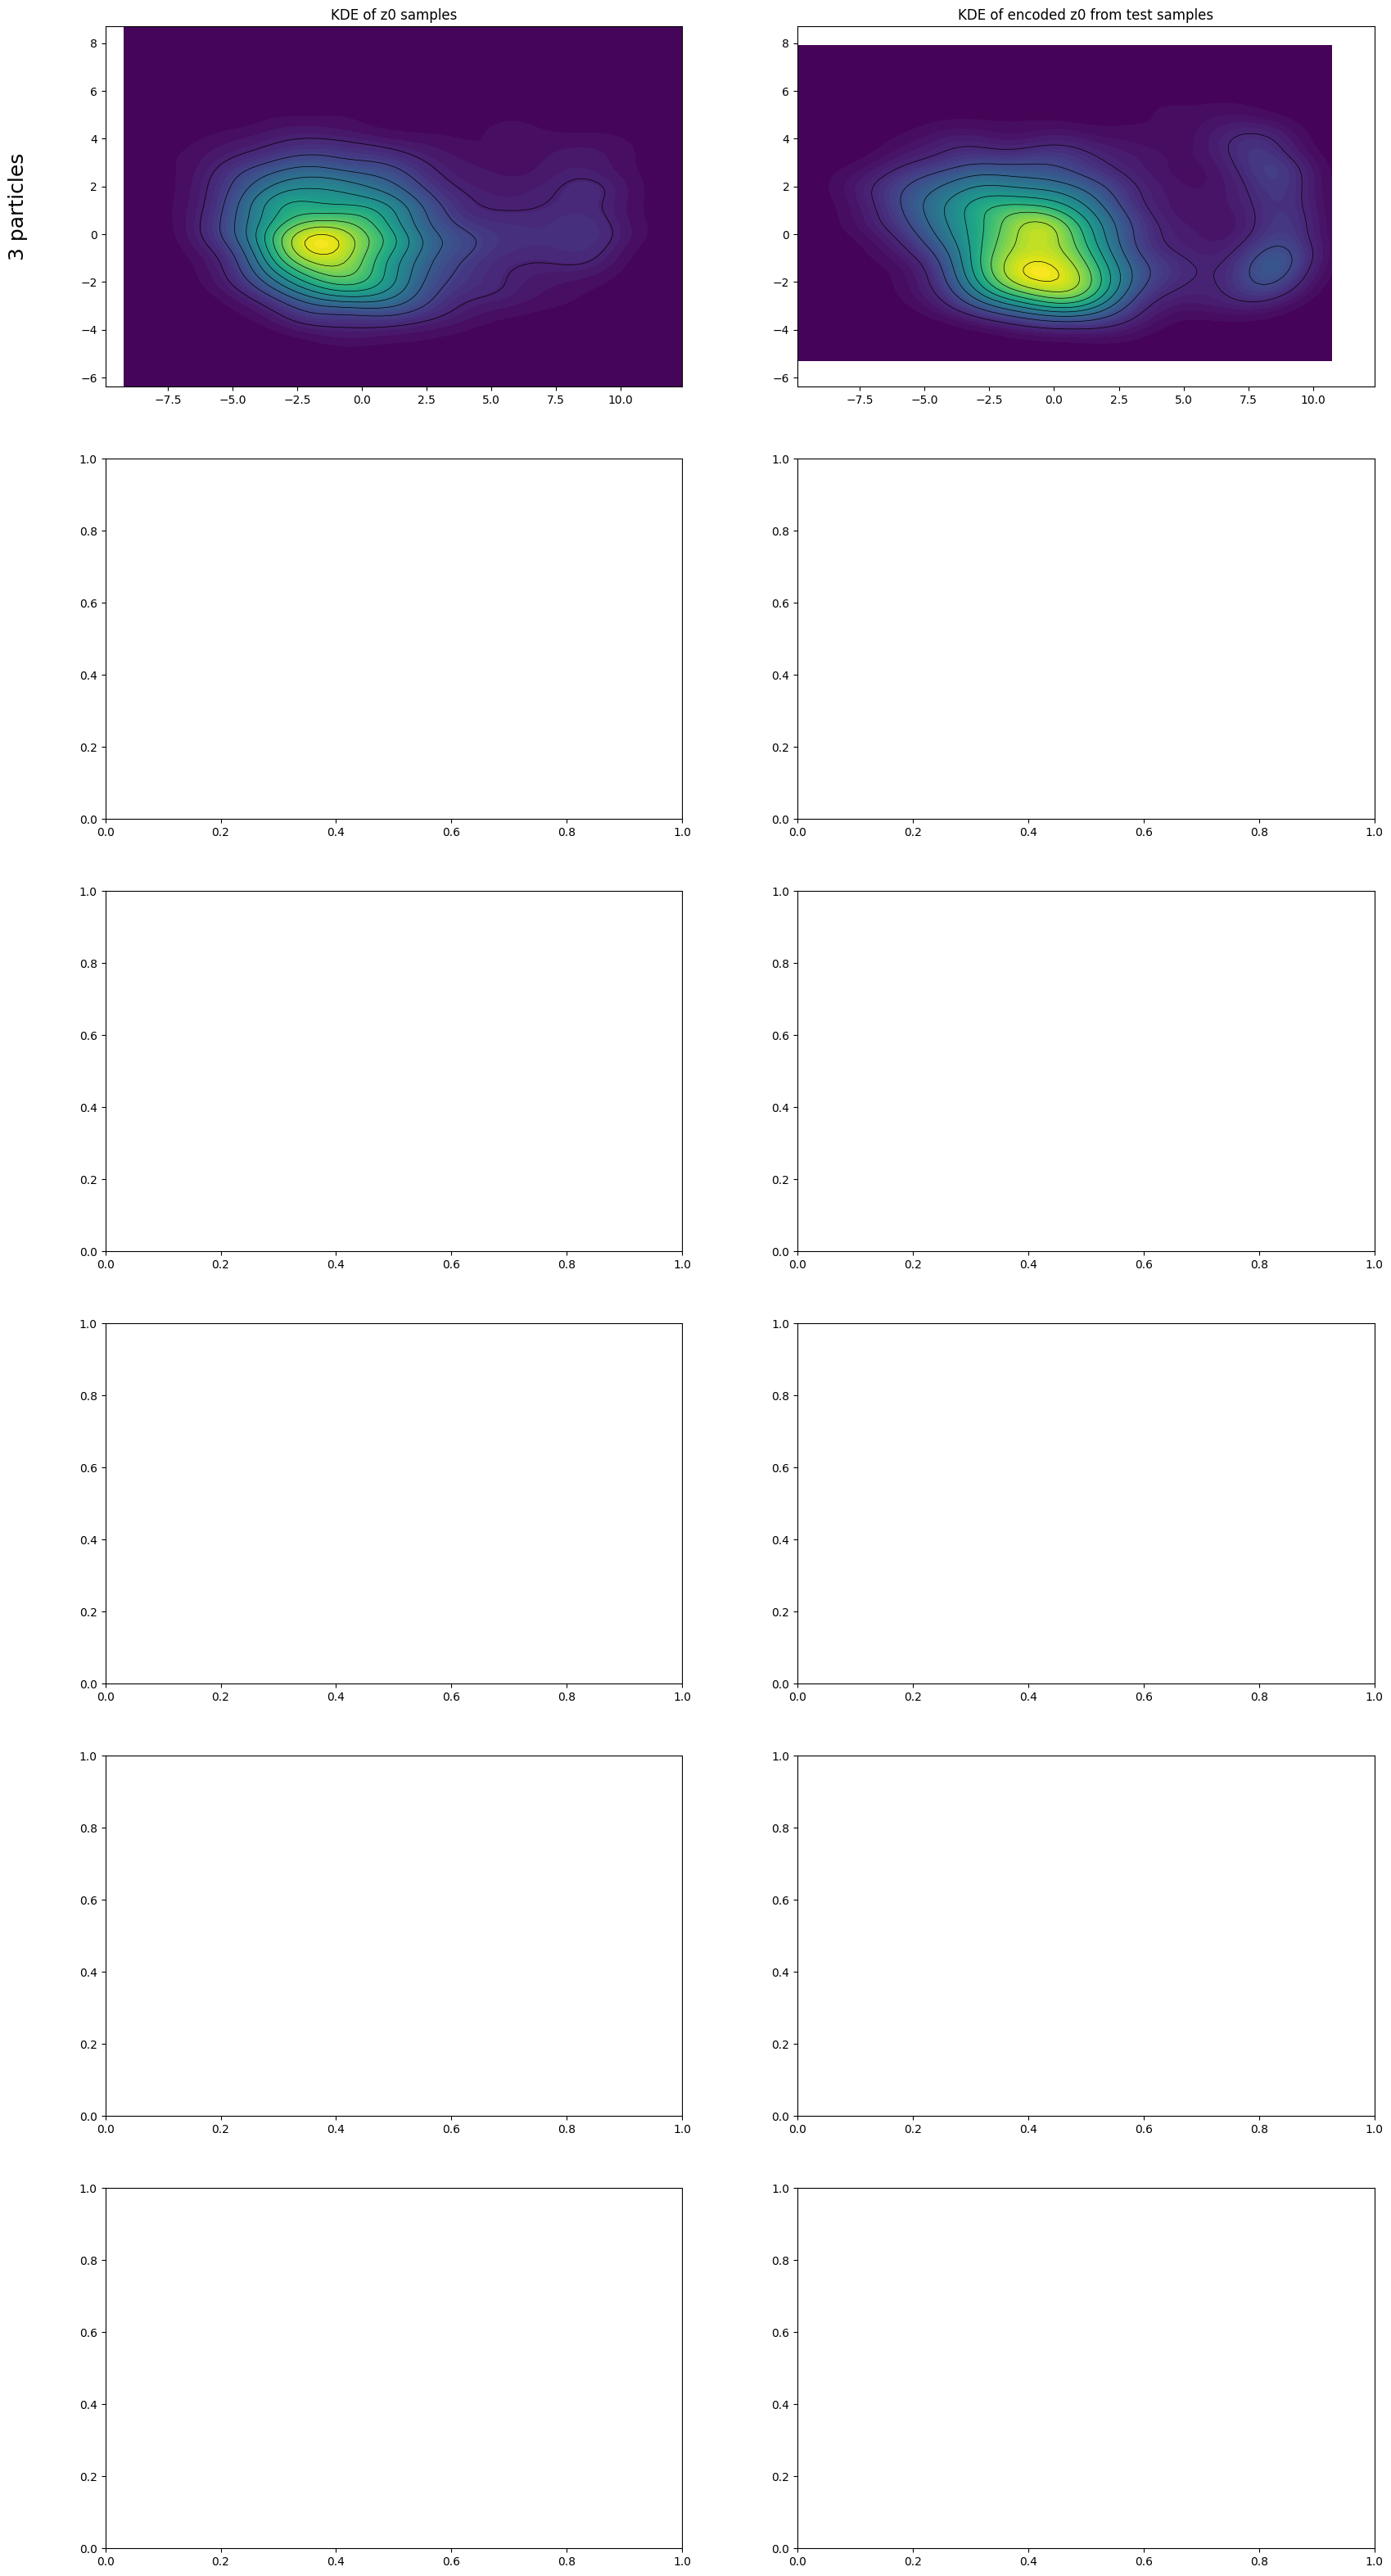

In [16]:

fig, ax = plt.subplots(6, 2, figsize=(20, 40))

for i, (num_particles, model, time_taken, particle_norms) in enumerate(trained_models):

    smivae74 = trained_models[i][1] # Get the model with 25 particles

    sites=smivae74.sample(sub_key, 3000)

    rng_key, sub_key = jax.random.split(rng_key)
    X_test_sample = X_test[np.random.choice(X_test.shape[0], 3000, replace=False)]
    encoded = smivae74.encode_batch(X_test_sample, sub_key)

    z0_embedding = pca.fit_transform(sites["z0"])
    z0_embedding_recon = pca.transform(encoded["z0"])



    #KDE
    kde = gaussian_kde(z0_embedding.T)
    x_min, x_max = z0_embedding[:, 0].min() - 1, z0_embedding[:, 0].max() + 1
    y_min, y_max = z0_embedding[:, 1].min() - 1, z0_embedding[:, 1].max() + 1
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords).reshape(xx.shape)
    ax[i, 0].contourf(xx, yy, density, levels=50, cmap="viridis")
    ax[i, 0].contour(xx, yy, density, levels=10, colors="black", linewidths=0.5)

    #KDE for reconstructions:
    kde_recon = gaussian_kde(z0_embedding_recon.T)
    x_min_recon, x_max_recon = z0_embedding_recon[:, 0].min() - 1, z0_embedding_recon[:, 0].max() + 1
    y_min_recon, y_max_recon = z0_embedding_recon[:, 1].min() - 1, z0_embedding_recon[:, 1].max() + 1
    xx_recon, yy_recon = np.mgrid[x_min_recon:x_max_recon:100j, y_min_recon:y_max_recon:100j]
    grid_coords_recon = np.vstack([xx_recon.ravel(), yy_recon.ravel()])
    density_recon = kde_recon(grid_coords_recon).reshape(xx_recon.shape)
    ax[i, 1].contourf(xx_recon, yy_recon, density_recon, levels=50, cmap="viridis")
    ax[i, 1].contour(xx_recon, yy_recon, density_recon, levels=10, colors="black", linewidths=0.5)

    #share axes
    x_min = min(x_min, x_min_recon)
    x_max = max(x_max, x_max_recon)
    y_min = min(y_min, y_min_recon)
    y_max = max(y_max, y_max_recon)
    ax[i, 0].set_xlim(x_min, x_max)
    ax[i, 0].set_ylim(y_min, y_max)
    ax[i, 1].set_xlim(x_min, x_max)
    ax[i, 1].set_ylim(y_min, y_max)
    ax[i, 0].set_title("KDE of z0 samples")
    ax[i, 1].set_title("KDE of encoded z0 from test samples")


    
    ax[i, 0].set_ylabel(
        f"{num_particles} particles",
        fontsize=18,
        rotation=90,
        labelpad=55,
        va="center"
    )

    
plt.show()


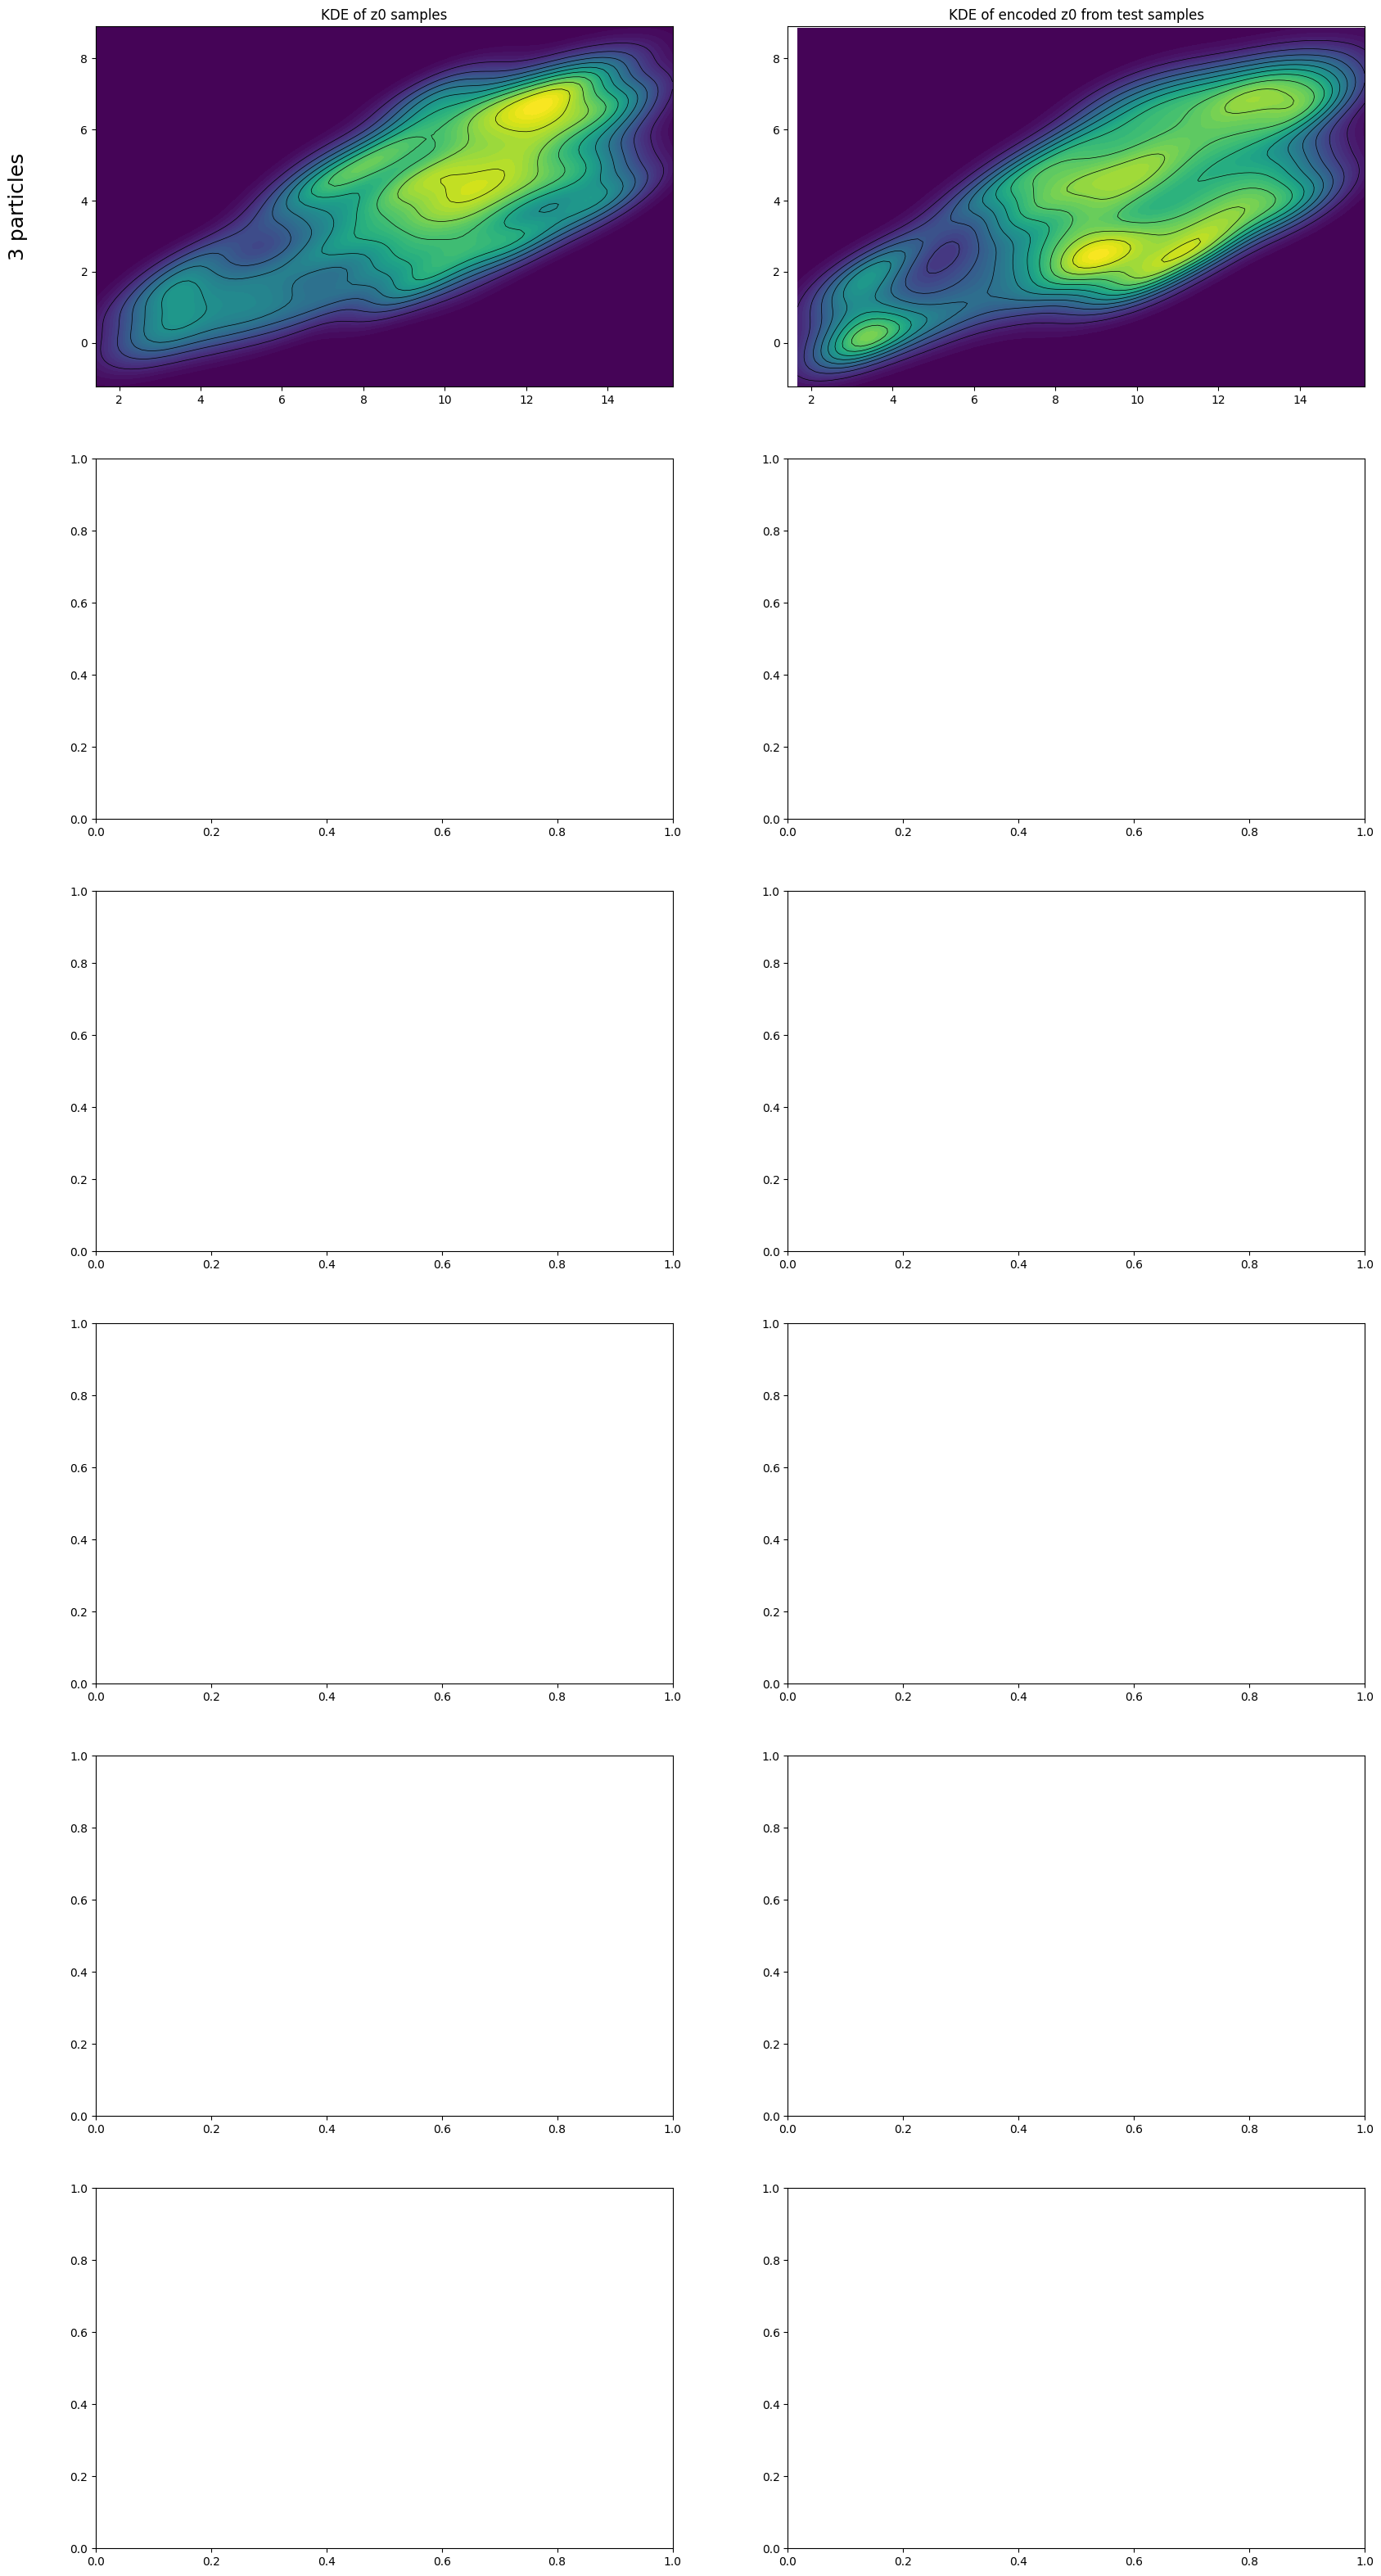

In [17]:
reducer = umap.UMAP()
fig, ax = plt.subplots(6, 2, figsize=(20, 40))

for i, (num_particles, model, time_taken, particle_norms) in enumerate(trained_models):

    smivae74 = trained_models[i][1] # Get the model with 25 particles

    sites=smivae74.sample(sub_key, 3000)

    rng_key, sub_key = jax.random.split(rng_key)
    X_test_sample = X_test[np.random.choice(X_test.shape[0], 3000, replace=False)]
    encoded = smivae74.encode_batch(X_test_sample, sub_key)

    z0_embedding = reducer.fit_transform(sites["z0"])
    z0_embedding_recon = reducer.transform(encoded["z0"])



    #KDE
    kde = gaussian_kde(z0_embedding.T)
    x_min, x_max = z0_embedding[:, 0].min() - 1, z0_embedding[:, 0].max() + 1
    y_min, y_max = z0_embedding[:, 1].min() - 1, z0_embedding[:, 1].max() + 1
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords).reshape(xx.shape)
    ax[i, 0].contourf(xx, yy, density, levels=50, cmap="viridis")
    ax[i, 0].contour(xx, yy, density, levels=10, colors="black", linewidths=0.5)

    #KDE for reconstructions:
    kde_recon = gaussian_kde(z0_embedding_recon.T)
    x_min_recon, x_max_recon = z0_embedding_recon[:, 0].min() - 1, z0_embedding_recon[:, 0].max() + 1
    y_min_recon, y_max_recon = z0_embedding_recon[:, 1].min() - 1, z0_embedding_recon[:, 1].max() + 1
    xx_recon, yy_recon = np.mgrid[x_min_recon:x_max_recon:100j, y_min_recon:y_max_recon:100j]
    grid_coords_recon = np.vstack([xx_recon.ravel(), yy_recon.ravel()])
    density_recon = kde_recon(grid_coords_recon).reshape(xx_recon.shape)
    ax[i, 1].contourf(xx_recon, yy_recon, density_recon, levels=50, cmap="viridis")
    ax[i, 1].contour(xx_recon, yy_recon, density_recon, levels=10, colors="black", linewidths=0.5)

    #share axes
    x_min = min(x_min, x_min_recon)
    x_max = max(x_max, x_max_recon)
    y_min = min(y_min, y_min_recon)
    y_max = max(y_max, y_max_recon)
    ax[i, 0].set_xlim(x_min, x_max)
    ax[i, 0].set_ylim(y_min, y_max)
    ax[i, 1].set_xlim(x_min, x_max)
    ax[i, 1].set_ylim(y_min, y_max)
    ax[i, 0].set_title("KDE of z0 samples")
    ax[i, 1].set_title("KDE of encoded z0 from test samples")


    
    ax[i, 0].set_ylabel(
        f"{num_particles} particles",
        fontsize=18,
        rotation=90,
        labelpad=55,
        va="center"
    )

    
plt.show()


In [18]:
smivae74 = trained_models[0][1] 
trained_models[0][0]

3

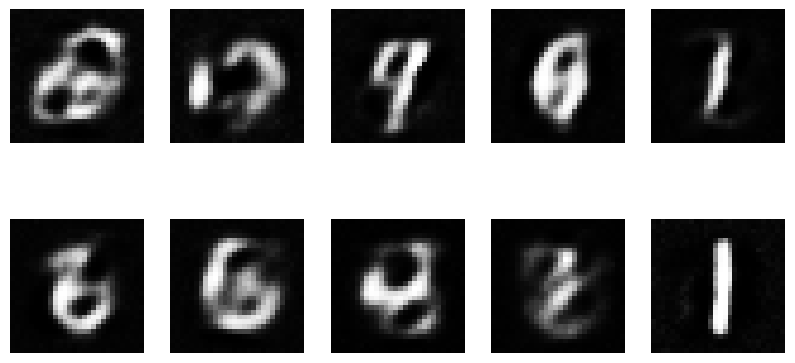

In [19]:
rng_key, sub_key = jax.random.split(rng_key)
plot_images(smivae74.sample(sub_key, 10)["x"], shape=(28, 28))

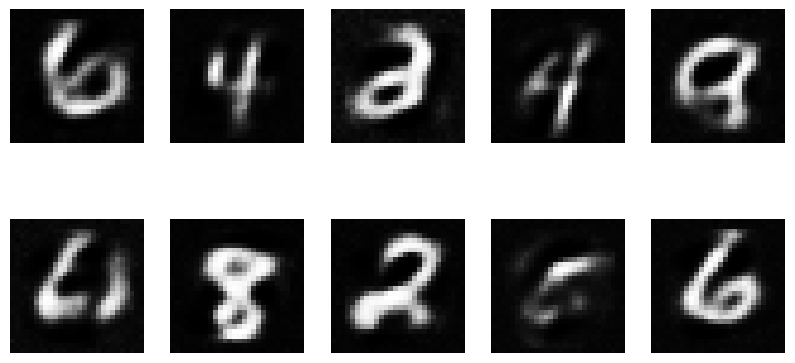

In [20]:
smivae74 = trained_models[0][1]

rng_key, sub_key = jax.random.split(rng_key)
X_test_sample = X_test[np.random.choice(X_test.shape[0], 10, replace=False)]
encoded = smivae74.encode_batch(X_test_sample, sub_key)

reconstructed = smivae74.decode_latent({"z0": encoded["z0"], "m": encoded["m"]}, sub_key, size_site="z0")["x"]
plot_images(reconstructed, shape=(28, 28))

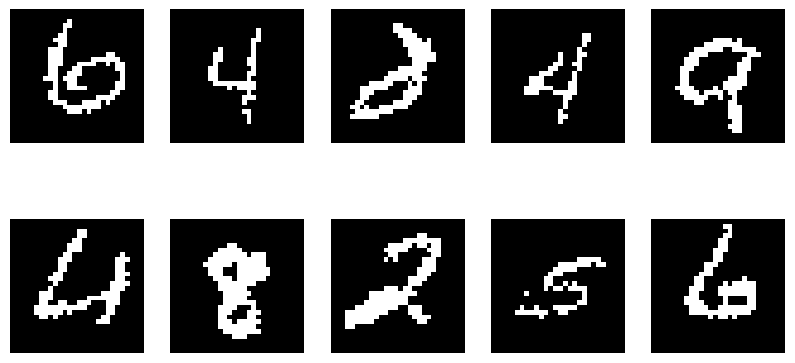

In [21]:

plot_images(X_test_sample, shape=(28, 28))

Test IWAE log likelihood on testdata

In [22]:
avg_iwaes = []
for model in trained_models:
    

    smivae74 = model[1]
    size = len(X_test)
    out = smivae74.evaluate_iwae(
        dataloader=dataloader_test,
        size=size,
        rng_key=jax.random.PRNGKey(1),
        num_particles=5000,
    )
    avg_iwaes.append(out["avg_iwae"])


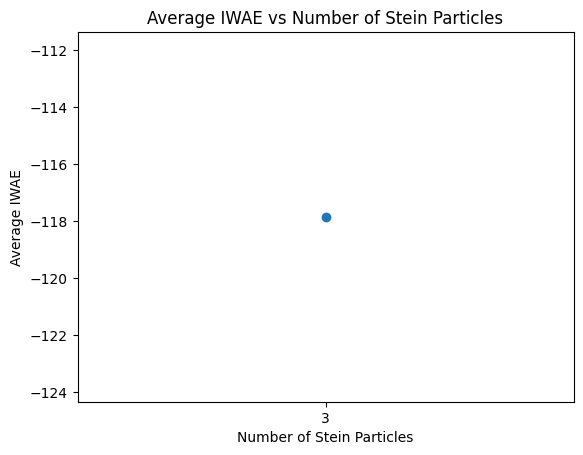

In [23]:
stein_particles_counts = [model[0] for model in trained_models]
plt.plot(stein_particles_counts, avg_iwaes, marker="o")
plt.title("Average IWAE vs Number of Stein Particles")
plt.xlabel("Number of Stein Particles")
plt.ylabel("Average IWAE")
plt.xticks(stein_particles_counts)
plt.show()

# Norm convergence


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stein_norms(per_particle_norms, title, iteration_slice=slice(None)):
    norms = np.asarray(jax.device_get(per_particle_norms))

    # norms shape: [iterations, particles]
    norms = norms[iteration_slice]

   

    iterations = np.arange(norms.shape[0])

    if iteration_slice.start is not None:
        iterations = iterations + iteration_slice.start

    mean_norm = norms.mean(axis=1)
    std_norm = norms.std(axis=1)
    max_norm = norms.max(axis=1)

    eps = 1e-12
    norms = np.maximum(norms, eps)
    mean_norm = np.maximum(mean_norm, eps)
    std_norm = np.maximum(std_norm, eps)
    max_norm = np.maximum(max_norm, eps)

    plt.figure(figsize=(14, 5))


    plt.semilogy(iterations, mean_norm, linewidth=2, label="mean")
    plt.semilogy(iterations, max_norm, linewidth=2, linestyle="--", label="max")
    plt.fill_between(iterations, mean_norm - std_norm, mean_norm + std_norm, color='blue', alpha=0.2, label="std")

    plt.xlabel("Iteration")
    plt.ylabel("Stein particle norm")
    plt.title(title)
    plt.legend()
    fig = plt.gcf()
    plt.show()
    return fig



def plot_individual_paths(per_particle_norms, title, iteration_slice=slice(None), window=3):

    norms = np.asarray(jax.device_get(per_particle_norms))

    # norms shape: [iterations, particles]
    norms = norms[iteration_slice]

    # add smoothing with a lag of 3 for each path
    norms =np.apply_along_axis(lambda m: np.convolve(m, np.ones(window)/window, mode='same'), axis=0, arr=norms)




    iterations = np.arange(norms.shape[0])

    if iteration_slice.start is not None:
        iterations = iterations + iteration_slice.start

    plt.figure(figsize=(14, 5))

    for i in range(norms.shape[1]):
        plt.semilogy(iterations, norms[:, i], linewidth=1, label=f"particle {i}")

    plt.xlabel("Iteration")
    plt.ylabel("Stein particle norm")
    plt.title(title)
    plt.legend()
    fig = plt.gcf()
    plt.show()

    # return image:
    return fig


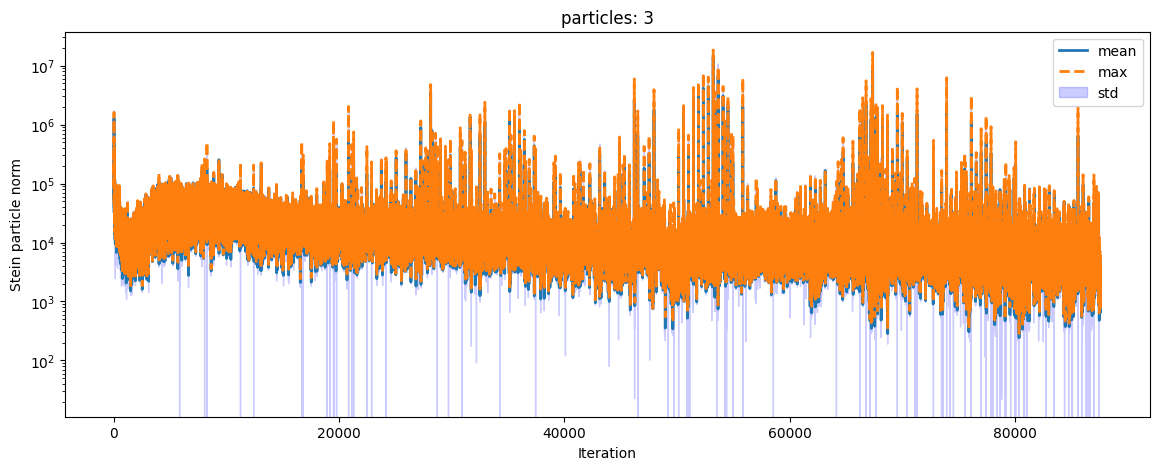

0

In [ ]:
plot_stein_norms(trained_models[0][3], f"particles: {trained_models[0][0]}")
